# Bottleneck analysis: HPC results

This notebook **only reads small result tables** from the HPC analysis script. It does not load checkpoints, image arrays, or feature caches, and does not import Torch or PennyLane. Run the processing on the HPC, copy back its exports, then Run all here.

The default experiment is `full128_array_12560`, comparing QUFEX with CNN replacement. The script performs branch interventions and linear probes without retraining the original networks.

## 1. Run the processing on HPC

The script reads the two `best.pt` checkpoints and all three processed splits.

## 2. Copy only the small results

Copy these **top-level files** from `/data/qmla/famato/results/bottleneck_analysis/full128_array_12560/` into local `results/bottleneck_analysis/full128_array_12560/`:

- `interventions.csv`
- `intervention_summary.csv`
- `probes.csv`
- `probe_selection.csv`
- `analysis_settings.json`
- Optionally, the two `.png` plots for viewing without Jupyter.

**Leave `features/`, the dataset, and the checkpoints on HPC.** This notebook regenerates plots from the CSVs. Restart your local kernel before using this version to release memory held by the earlier processing notebook. Change the path below if you copy results elsewhere.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "configs" / "experiments.toml").is_file()
)
pd.set_option("display.max_columns", 30)

In [ ]:
RUN_ID = "12560"  # Also supports "12546" and "12554" after processing those runs.
RESULTS_ROOT = ROOT / "results" / "bottleneck_analysis"
EXPERIMENT = f"full128_array_{RUN_ID}"
OUTPUT_DIR = RESULTS_ROOT / EXPERIMENT
MODELS = ("qufex", "cnn_replacement")

settings = json.loads((OUTPUT_DIR / "analysis_settings.json").read_text(encoding="utf-8"))
interventions = pd.read_csv(OUTPUT_DIR / "interventions.csv")
intervention_summary = pd.read_csv(OUTPUT_DIR / "intervention_summary.csv")
probes = pd.read_csv(OUTPUT_DIR / "probes.csv")
probe_selection = pd.read_csv(OUTPUT_DIR / "probe_selection.csv")
print(f"Results: {OUTPUT_DIR}")
display(pd.DataFrame(settings["checkpoints"]).T)
print(f"HPC device: {settings['device']} | Batch size: {settings['batch_size']}")

Results: g:\MALTA\code\qmla\results\bottleneck_analysis\full128_array_12560


,path,dataset_id,epoch,seed,amp
qufex,/data/qmla/famato/checkpoints/full128_array_12...,9793e662d43a2596fb56bf131c7ee99882ed5adca9ab14...,39,42,True
cnn_replacement,/data/qmla/famato/checkpoints/full128_array_12...,9793e662d43a2596fb56bf131c7ee99882ed5adca9ab14...,37,42,True


HPC device: cuda | Batch size: 32


## 1. Intervene on the trained bottleneck

Write the model as `head(z + b)`, where `z` is the compressed representation and `b` is the QUFEX or CNN branch. The head includes the post-bottleneck convolutions, global pooling, and classifier.

Compare original, removed, half-strength, and shuffled branches. Shuffling pairs each image with another position's branch output using a whole-test-set permutation. The same five seeds give the same permutations for both models because the shared dataset is read in manifest order. Permutations are not constrained to avoid occasional fixed points.

Everything stays in evaluation mode, including BatchNorm and dropout. No parameters are updated. A performance drop shows **dependence on this branch in the trained model**; it does not tell us whether the surrounding network could compensate after retraining.

,experiment,model,variant,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,cross_entropy_mean,cross_entropy_std,f1_smooth_mean,f1_smooth_std,f1_unbarred_spiral_mean,f1_unbarred_spiral_std,f1_barred_spiral_mean,f1_barred_spiral_std,delta_accuracy_mean,delta_accuracy_std,delta_macro_f1_mean,delta_macro_f1_std,delta_cross_entropy_mean,delta_cross_entropy_std,delta_f1_smooth_mean,delta_f1_smooth_std,delta_f1_unbarred_spiral_mean,delta_f1_unbarred_spiral_std,delta_f1_barred_spiral_mean,delta_f1_barred_spiral_std
0,full128_array_12560,qufex,original,0.8192,0.0000,0.8086,0.0000,0.4597,0.0000,0.8699,0.0000,0.7271,0.0000,0.8288,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,full128_array_12560,qufex,removed,0.8201,0.0000,0.8081,0.0000,0.4605,0.0000,0.8717,0.0000,0.7260,0.0000,0.8267,0.0000,0.0009,0.0000,-0.0005,0.0000,0.0007,0.0000,0.0018,0.0000,-0.0011,0.0000,-0.0021,0.0000
2,full128_array_12560,qufex,half_strength,0.8202,0.0000,0.8092,0.0000,0.4595,0.0000,0.8710,0.0000,0.7280,0.0000,0.8284,0.0000,0.0010,0.0000,0.0006,0.0000,-0.0003,0.0000,0.0011,0.0000,0.0009,0.0000,-0.0004,0.0000
3,full128_array_12560,qufex,shuffled,0.8167,0.0008,0.8056,0.0009,0.4782,0.0008,0.8681,0.0010,0.7232,0.0011,0.8257,0.0014,-0.0025,0.0008,-0.0029,0.0009,0.0184,0.0008,-0.0018,0.0010,-0.0039,0.0011,-0.0031,0.0014
4,full128_array_12560,cnn_replacement,original,0.8139,0.0000,0.8049,0.0000,0.4761,0.0000,0.8645,0.0000,0.7295,0.0000,0.8207,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,full128_array_12560,cnn_replacement,removed,0.8134,0.0000,0.8013,0.0000,0.4908,0.0000,0.8669,0.0000,0.7303,0.0000,0.8066,0.0000,-0.0005,0.0000,-0.0036,0.0000,0.0147,0.0000,0.0024,0.0000,0.0008,0.0000,-0.0141,0.0000
6,full128_array_12560,cnn_replacement,half_strength,0.8230,0.0000,0.8110,0.0000,0.4588,0.0000,0.8747,0.0000,0.7367,0.0000,0.8217,0.0000,0.0091,0.0000,0.0061,0.0000,-0.0173,0.0000,0.0102,0.0000,0.0072,0.0000,0.0010,0.0000
7,full128_array_12560,cnn_replacement,shuffled,0.8153,0.0005,0.8062,0.0006,0.4736,0.0005,0.8659,0.0003,0.7328,0.0007,0.8199,0.0010,0.0014,0.0005,0.0013,0.0006,-0.0025,0.0005,0.0014,0.0003,0.0033,0.0007,-0.0008,0.0010


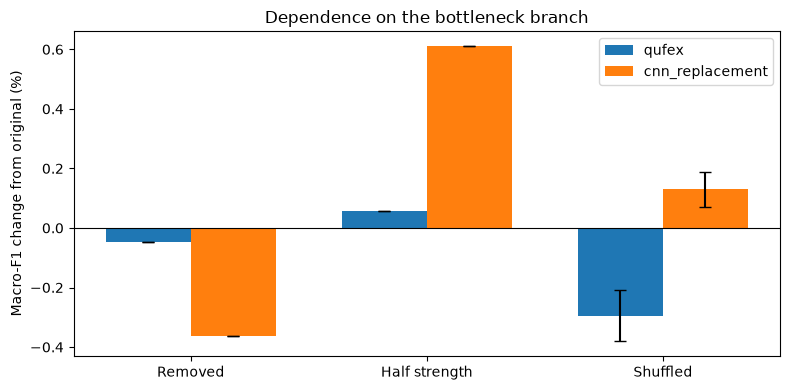

In [8]:
display(intervention_summary.round(4))

variants = ("removed", "half_strength", "shuffled")
x = np.arange(len(variants))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
for index, mode in enumerate(MODELS):
    frame = intervention_summary[intervention_summary["model"] == mode].set_index("variant").loc[list(variants)]
    ax.bar(
        x + (index - 0.5) * width,
        100 * frame["delta_macro_f1_mean"],
        width, label=mode,
        yerr=100 * frame["delta_macro_f1_std"], capsize=4,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, ("Removed", "Half strength", "Shuffled"))
ax.set_ylabel("Macro-F1 change from original (%)")
ax.set_title(f"Dependence on the bottleneck branch")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "intervention_macro_f1.png", dpi=180)
plt.show()

All deltas are **intervention minus original**: negative F1/accuracy deltas and positive cross-entropy deltas indicate worse performance. Cross-entropy is unweighted and uses natural logarithms.

Shuffled results are averaged over five permutations. Their standard deviation describes **permutation variability**, not uncertainty across independent training runs. Single-evaluation rows have zero plotted error bars.

A large removal/shuffling effect indicates that the head uses the branch. A small effect suggests limited dependence on this test set. Neither result alone proves that optimizing QUFEX's parameters was useful.

## 2. Measure class separability with linear probes

The HPC script uses cached, frozen features to fit three independent probes per model:

- **Compression:** flattened `z`.
- **Branch:** flattened `b`.
- **Residual sum:** flattened `z + b`.

Each fitted probe is a StandardScaler followed by logistic regression with balanced class weights. Fit both the scaler and classifier on **training data only**. Select regularization using **validation macro-F1**, then report test metrics once for the selected probe. No model selection uses test scores.

The four C values are considered in ascending order; an exact validation-score tie keeps the smaller C. Convergence warnings remain visible. Only these small classifiers are trained.

In [4]:
display(probes.round(4))
display(probe_selection.round(4))

,experiment,model,representation,selected_C,validation_macro_f1,accuracy,macro_f1,cross_entropy,f1_smooth,f1_unbarred_spiral,f1_barred_spiral,delta_macro_f1_vs_compression
0,full128_array_12560,qufex,compression,0.10,0.8031,0.8120,0.8027,0.4687,0.8630,0.7231,0.8220,0.0000
1,full128_array_12560,qufex,branch,1.00,0.7944,0.8087,0.7981,0.4791,0.8621,0.7164,0.8158,-0.0046
2,full128_array_12560,qufex,residual_sum,10.00,0.7993,0.8113,0.8017,0.4686,0.8627,0.7218,0.8207,-0.0010
3,full128_array_12560,cnn_replacement,compression,0.01,0.7978,0.8104,0.7991,0.4747,0.8648,0.7195,0.8131,0.0000
4,full128_array_12560,cnn_replacement,branch,10.00,0.7575,0.7862,0.7653,0.5196,0.8640,0.6620,0.7701,-0.0338
5,full128_array_12560,cnn_replacement,residual_sum,0.01,0.7974,0.8104,0.7991,0.4749,0.8649,0.7193,0.8131,-0.0000


,experiment,model,representation,C,validation_macro_f1
0,full128_array_12560,qufex,compression,0.01,0.8027
1,full128_array_12560,qufex,compression,0.10,0.8031
2,full128_array_12560,qufex,compression,1.00,0.8028
3,full128_array_12560,qufex,compression,10.00,0.8026
4,full128_array_12560,qufex,branch,0.01,0.7940
5,full128_array_12560,qufex,branch,0.10,0.7938
6,full128_array_12560,qufex,branch,1.00,0.7944
7,full128_array_12560,qufex,branch,10.00,0.7940
8,full128_array_12560,qufex,residual_sum,0.01,0.7982
9,full128_array_12560,qufex,residual_sum,0.10,0.7983


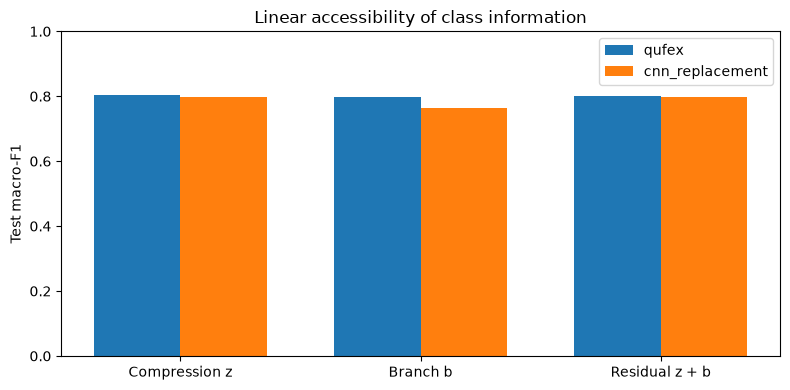

Residual-sum probe improvement over compression (percentage points):


,delta_macro_f1_vs_compression
model,
qufex,-0.1
cnn_replacement,-0.0


Local tables, plots, and settings: g:\MALTA\code\qmla\results\bottleneck_analysis\full128_array_12560


In [7]:
representations = ("compression", "branch", "residual_sum")
x = np.arange(len(representations))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
for index, mode in enumerate(MODELS):
    frame = probes[probes["model"] == mode].set_index("representation").loc[list(representations)]
    ax.bar(x + (index - 0.5) * width, frame["macro_f1"], width, label=mode)
ax.set_xticks(x, ("Compression z", "Branch b", "Residual z + b"))
ax.set_ylabel("Test macro-F1")
ax.set_ylim(0, 1)
ax.set_title(f"Linear accessibility of class information")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "probe_macro_f1.png", dpi=180)
plt.show()

print("Residual-sum probe improvement over compression (percentage points):")
display(
    probes[probes["representation"] == "residual_sum"]
    .set_index("model")[["delta_macro_f1_vs_compression"]].mul(100).round(2)
)
print(f"Local tables, plots, and settings: {OUTPUT_DIR}")

## What to conclude

Read the intervention and probe results together:

- A branch-removal/shuffling penalty shows that the trained head depends on the branch.
- A better probe on `z + b` than on `z` indicates that the residual representation makes labels more accessible to a linear classifier.
- A strong branch-only probe shows that the branch carries decodable class information; it does not prove that the downstream head uses it.
- QUFEX and CNN replacement have separately trained compression networks. Compare the before/after changes within each model; their absolute scores do not isolate the bottleneck on identical inputs.

These are checkpoint-specific observations, not percentages of learning attributable to each component. They do not establish that **training the circuit parameters** caused the benefit; that requires a trained-versus-frozen-QUFEX experiment.

Changing the run ID allows the same analysis for `12546` or `12554`. Those runs also use seed 42 and differ in training settings, so do not treat them as independent-seed repetitions.